# PCHN63112 Workshop 1: Introducing GLMs

## Alternative Distributions in `R`

## The Exponential Family
To see how the exponential form can be turned into different distributions, we will give a few examples before showing these with some actual numbers in `R` below. In all cases, do not get too hung up on the mathematics itself. The more important element is understanding that different distributions can all be represented using the same formula, and that it is this shared formula that allows for a generic modelling framework that is not restricted to just a single distribution.

### Example in `R`

In [ ]:
dexp_family <- function(y,theta,phi,A,B,C){
  exp(((y*theta - B(theta))/A(phi)) + C(y,phi))
}

Now all we have to do is provide a value for `y`, `theta` and `phi`, as well as definitions of `A(phi)`, `B(theta)` and `C(y,theta)`. Depending on these choices, we can turn the `pexp_family()` function into a variety of different distribution. 

For example, we can create a normal distribution using:

In [ ]:
# Definitions of a(phi), b(theta) and c(y,phi)
A <- function(phi){     
         phi                          
     } 

B <- function(theta){  
         (theta^2)/2                   
     }

C <- function(y,phi){ 
         -((y^2)/phi + log(2*pi*phi))/2 
     }

# Parameters of the original distribution
mu    <- 5
sigma <- 2

# Parameters of the exponential form
theta <- mu 
phi   <- sigma^2

# Example data value
y <- c(7,5,9,8,2,4)

print(dexp_family(y,theta,phi,A,B,C)) # density from exponential family
print(dnorm(y,mu,sigma))              # density of normal distribution

[1] 0.12098536 0.19947114 0.02699548 0.06475880 0.06475880 0.17603266
[1] 0.12098536 0.19947114 0.02699548 0.06475880 0.06475880 0.17603266


The value for the density of the distribution when $y = 7$ is identical whether we use the exponential form or the standard form of the normal distribution, illustrating how the same distribution can be defined both ways. We could also create a Poisson distribution using the same structure with:

In [ ]:
a <- function(phi){    1                 }
b <- function(theta){  exp(theta)        }
c <- function(y,phi){ -log(factorial(y)) }

# Parameters of the original distribution
mu <- 2

# Parameters of the exponential form
theta <- log(mu)
phi   <- 1

# Data value
y <- 7

print(dexp_family(y,theta,phi,a,b,c)) # density from exponential family
print(dpois(y,mu))                    # density of Poisson distribution

[1] 0.003437087
[1] 0.003437087


Again, the densities are identical. A binomial distribution is the same. If we fix the number of trial to $n = 5$, we have:

In [ ]:
a <- function(phi){   1                     }
b <- function(theta){ 5*log(1 + exp(theta)) }
c <- function(y,phi){ log(choose(5,y))      }

# Parameters of the original distribution
n <- 5
p <- 0.8

# Parameters of the exponential form
theta <- log(p/(1-p))
phi   <- 1

# Data value
y <- 3

print(dexp_family(y,theta,phi,a,b,c)) # density from exponential family
print(dbinom(y,n,p))                  # density of Binomial distribution

[1] 0.2048
[1] 0.2048


So, we can see in each case that the generic form of a distribution from the exponential family can be used to define a variety of different distributions, simply by changing a few of the parameters. Having all these distributions fall under the same mathematical formulation is very powerful because if we have a modelling framework based around the general exponential form of a distribution, we can then apply that framework generically to many different distributions. So, rather than being stuck using the normal distribution for everything, we suddenly have a choice in the assumed distribution of the data. Even more simply, we can now analyse binary, counts, proportions and ordinal outcomes, as well as continuous outcomes, opening up a much wider range of variables we can model.

## Link Functions

## Asymptotic Distributions
... We can demonstrate these ideas using simulations. In particular, we can show how unreliable these approximations are when $n$ is small, which should give you some sense of how much $p$-values can be relied upon in small samples.

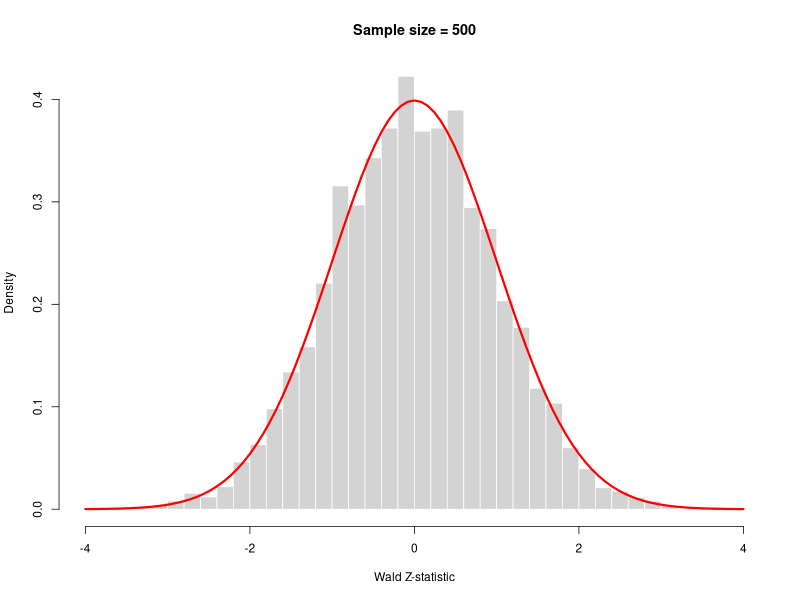

In [52]:
# Simulation Parameters
set.seed(666)
n      <- 500
lambda <- 2
n.sim  <- 10000

# Simulate Wald Z-statistics (under the null)
wald <- replicate(n.sim, {

  # Sample from Poisson distribution
  y <- rpois(n, lambda)

  # Estimate lambda
  lambda.hat <- mean(y)

  # sqrt(W) 
  (lambda.hat - lambda) / sqrt(lambda.hat / n)
})

# Plot the distribution
hist(wald, 
     probability = TRUE, 
     breaks      = 50,
     col         = "lightgrey", 
     border      = "white",
     xlab        = "Wald Z-statistic",
     main        = paste("Sample size =",n),
     xlim        = c(-4,4))

# Add standard normal curve
curve(dnorm(x), 
      add = TRUE, 
      col = "red", 
      lwd = 3)


<div class="alert alert-block alert-success"><b>Exercise #:</b> 

Copy the code above into an <code>R</code> script and then try changing the value of <code>n</code> to different sizes. What happens to the accuracy of the distribution when <code>n <- 5</code> or <code>n <- 10</code>? At what point does the sample size seem large enough for the distribution to converge on a standard normal? 

Next, try changing the value of <code>lambda</code>. Does the point where the distribution converges change? What does this tell you about the definition of a sample that is "large enough"?
</div>